<a href="https://colab.research.google.com/github/ewg-sl/Colab_Notebooks/blob/main/%D0%9F%D0%BE%D1%82%D1%80%D0%B5%D0%B1%D0%BB%D0%B5%D0%BD%D0%B8%D0%B5_%D1%8D%D0%BB%D0%B5%D0%BA%D1%82%D1%80%D0%BE%D1%8D%D0%BD%D0%B5%D1%80%D0%B3%D0%B8%D0%B8_(%D0%B2%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D0%B5_%D1%80%D1%8F%D0%B4%D1%8B).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Описание

- В наборе данных нет пропущенных значений.  
- Значения указаны в киловаттах за каждые 15 минут.  Чтобы перевести значения в киловатт-часы, их нужно разделить на 4.  
- Каждый столбец соответствует одному клиенту.
- Некоторые клиенты были созданы после 2011 года. В этих случаях потребление считалось нулевым.
- Все временные метки указаны в португальских часах. Однако во всех днях по 96 измерений (24*4).
- Каждый год в день перехода на зимнее время в марте (когда в сутках всего 23 часа) значения с 01:00 до 02:00 равны нулю для всех точек.
- Каждый год в день перехода на зимнее время в октябре (когда в сутках 25 часов) значения с 01:00 до 02:00 суммируют потребление за два часа.

---

Набор данных был сохранен в формате txt с использованием формата csv и разделителя-точки с запятой (;).
- В первом столбце дата и время представлены в виде строки в следующем формате: 'гггг-мм-дд чч:мм:сс'
- В остальных столбцах представлены значения с плавающей запятой, отражающие потребление в кВт


# Библиотеки

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, make_scorer

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy.stats import boxcox
from scipy.special import inv_boxcox

import warnings
warnings.filterwarnings('ignore')

# Функции

In [ ]:
def train_model(X, y, model_grid, test_size):
    result = {}
    try:
        model_name = type(model_grid['model']['regressor']).__name__
    except:
        model_name = type(model_grid['model']).__name__

    # Разделяем данные с сохранением последовательности (ибо временной ряд)
    split_idx = int(len(X) * (1 - test_size))

    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    search = GridSearchCV(
        estimator=model_grid['model'],
        param_grid=model_grid['params'],
        scoring=scoring,
        refit='rmse',
        cv=tscv,
        n_jobs=-1
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    # Метрики на CV
    train_rmse = abs(search.best_score_)
    train_mape = abs(search.cv_results_['mean_test_mape'][search.best_index_])

    # Метрики на тесте
    y_pred_test = best_model.predict(X_test)

    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100

    result[model_name] = {'model': best_model,
                          'RMSE': test_rmse,
                          'MAPE': test_mape}

    print(f"{model_name} RMSE train/test: {train_rmse:.1f} / {test_rmse:.1f}")
    print(f"{model_name} MAPE train/test: {train_mape:.3f}% / {test_mape:.3f}%")
    return result

In [ ]:
def comp_chart(y, y_pred, N):
    results_df = pd.DataFrame({
        'actual': y,
        'predicted': y_pred
    })

    # Фильтруем данные за последние N дней
    filtered_df = results_df.tail(N*24)

    plt.figure(figsize=(16, 8))

    plt.plot(
        filtered_df.index,
        filtered_df['actual'],
        label='Фактические значения',
        color='blue',
        linewidth=2,
        alpha=0.8
    )

    plt.plot(
        filtered_df.index,
        filtered_df['predicted'],
        label='Предсказанные значения',
        color='seagreen',
        linewidth=2,
        linestyle='--',
        alpha=0.8
    )

    # Настраиваем график
    plt.title(f'Фактические vs предсказанные значения за {N} дней',
            fontsize=14, fontweight='bold')
    plt.xlabel('Дата', fontsize=12)
    plt.ylabel('Потребление', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Улучшаем отображение дат на оси X: показываем только даты без времени для читаемости
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d.%m.%Y'))
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Показываем график
    plt.show()

# Глобальные переменные

In [ ]:
random_seed = 654321
test_size = 0.3
tscv = TimeSeriesSplit(n_splits=5)  # кол-во фолдов при кросс валидации

# Загрузка датасета

In [ ]:
path = "/content/drive/MyDrive/Экосистема альфа/5. Потребление электроэнергии (временные ряды)/LD2011_2014.txt"
data = pd.read_csv(path, sep=";", decimal=',', parse_dates=[0])

In [ ]:
# переименовываем столбцы и устанавливаем дату как индекс
new_columns = ['datetime'] + [f'cl_{i}' for i in range(1, len(data.columns))]
data.columns = new_columns
data.set_index('datetime', inplace=True)

In [ ]:
# делим все значения на 4, чтобы получить киловатт/часы
data = data.div(4)

In [ ]:
# агрегируем строки, чтобы все данные были по часам а не по 15 минут
data_h = data.resample('H').sum()

In [ ]:
data_h.head()

,cl_1,cl_2,cl_3,cl_4,cl_5,cl_6,cl_7,cl_8,cl_9,cl_10,...,cl_361,cl_362,cl_363,cl_364,cl_365,cl_366,cl_367,cl_368,cl_369,cl_370
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
data_h.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35065 entries, 2011-01-01 00:00:00 to 2015-01-01 00:00:00
Freq: h
Columns: 370 entries, cl_1 to cl_370
dtypes: float64(370)
memory usage: 99.3 MB


# Анализ клиентов

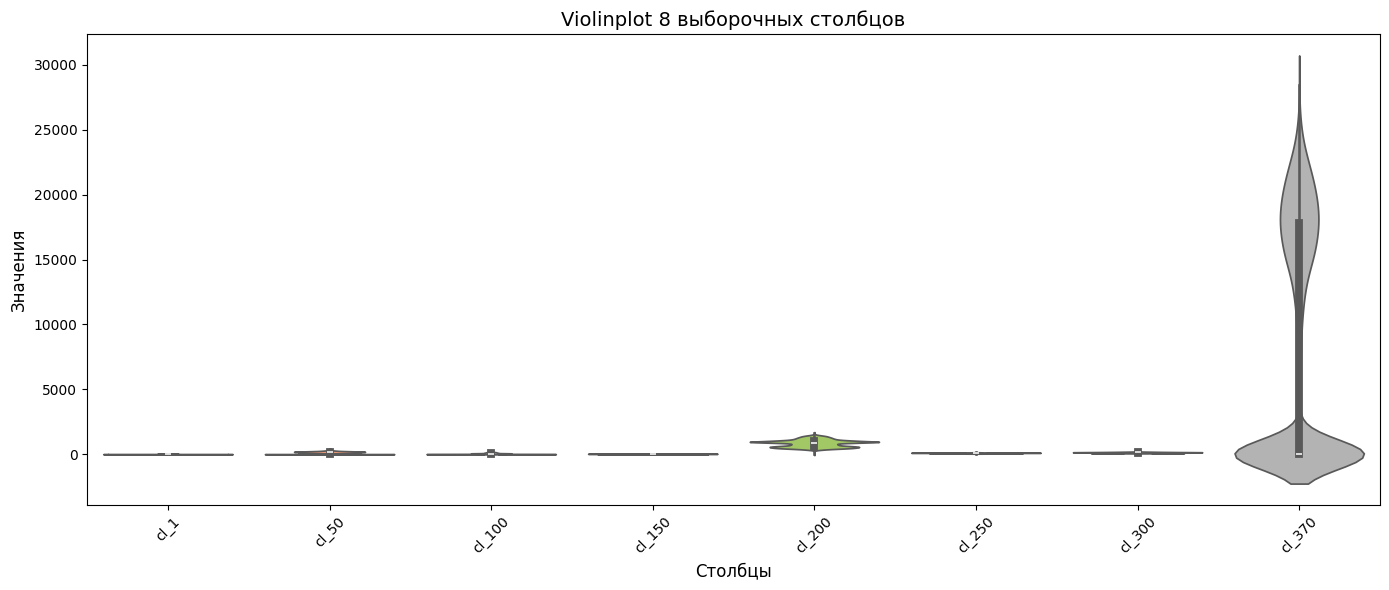

In [ ]:
# Или конкретные столбцы
sample_columns = ['cl_1', 'cl_50', 'cl_100', 'cl_150', 'cl_200', 'cl_250', 'cl_300', 'cl_370']

# Создаём melted DataFrame только для выбранных столбцов
data_h_sample = data_h[sample_columns].melt(var_name='column', value_name='value')


plt.figure(figsize=(14, 6))
sns.violinplot(data=data_h_sample, x='column', y='value', palette='Set2')
plt.title(f'Violinplot {len(sample_columns)} выборочных столбцов', fontsize=14)
plt.xlabel('Столбцы', fontsize=12)
plt.ylabel('Значения', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

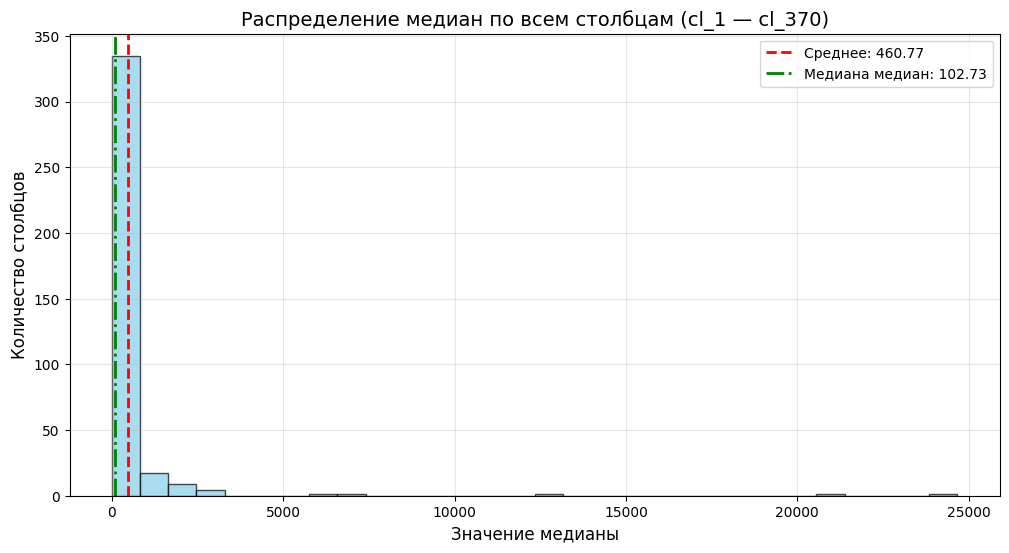

In [ ]:
medians = data_h.median()

plt.figure(figsize=(12, 6))
plt.hist(medians, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(medians.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {medians.mean():.2f}')
plt.axvline(medians.median(), color='green', linestyle='-.', linewidth=2, label=f'Медиана медиан: {medians.median():.2f}')

plt.title('Распределение медиан по всем столбцам (cl_1 — cl_370)', fontsize=14)
plt.xlabel('Значение медианы', fontsize=12)
plt.ylabel('Количество столбцов', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Преобразуем датасет по клиентам в датасет по суммарному потреблению

In [ ]:
s_sum = data_h.sum(axis=1)
s_sum.rename('total_cons', inplace=True)
# Создаём DataFrame для удобства работы
df_sum = pd.DataFrame({'total_cons': s_sum})

# Feature engineering

In [ ]:
# Добавляем столбцы с годом, месяцем, днём недели и часом, и флаг является ли день выходным
df_sum['hour'] = df_sum.index.hour
df_sum['year'] = df_sum.index.year
df_sum['month'] = df_sum.index.month
df_sum['day_of_week'] = df_sum.index.dayofweek
df_sum['is_weekend'] = (df_sum['day_of_week'] >= 5).astype(int)

# Лаги (историческое потребление) — ключевые для прогноза
for lag in [1, 2, 3, 6, 12, 24]:
    df_sum[f'lag_{lag}'] = df_sum['total_cons'].shift(lag)

# Скользящие средние (убираем шум)
df_sum['rolling_mean_24'] = df_sum['total_cons'].rolling(window=24).mean()  # сутки
df_sum['rolling_mean_168'] = df_sum['total_cons'].rolling(window=168).mean()  # неделя

# Разность с лагами (помогает при нестационарности)
df_sum['diff_1'] = df_sum['total_cons'].diff(1)

# Заполняем NaN от сдвигов (первые часы)
df_sum.dropna(inplace=True)

# Графики распределений

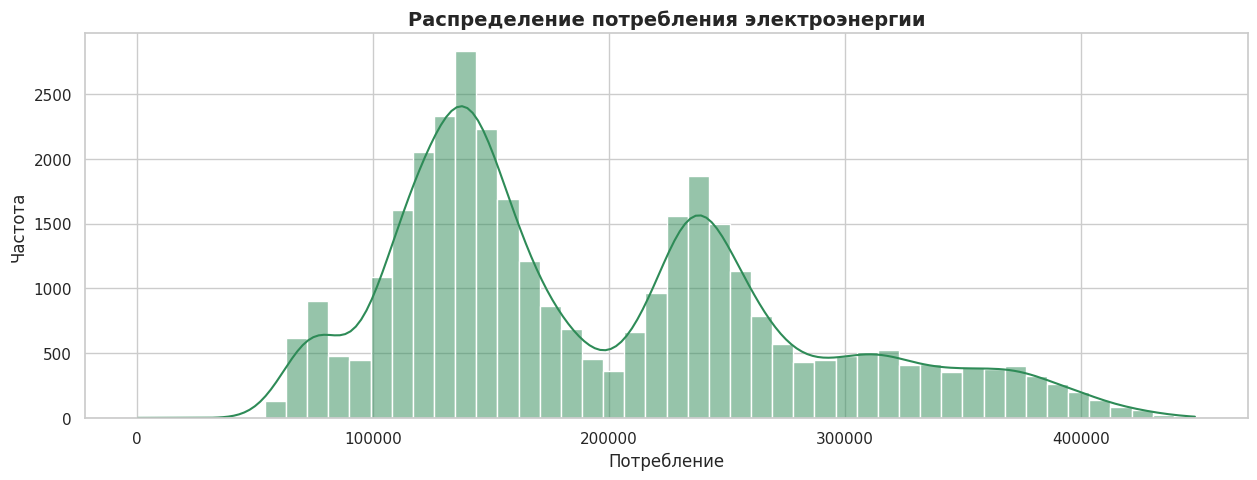

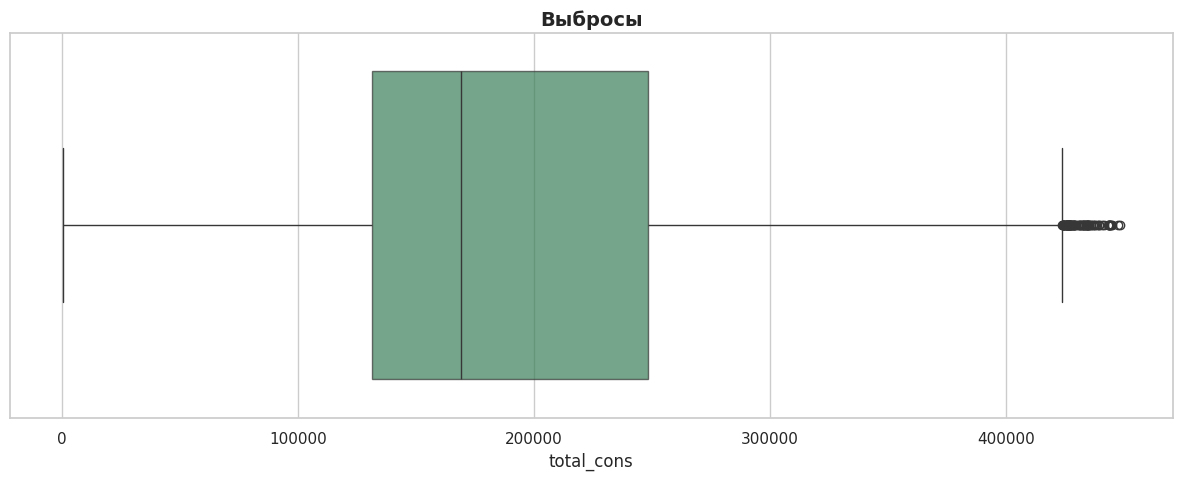

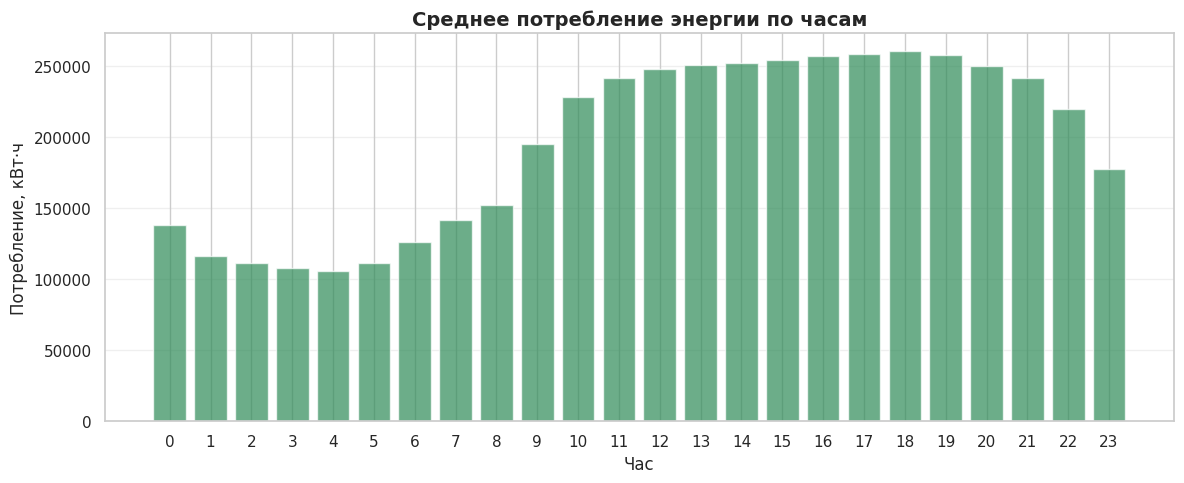

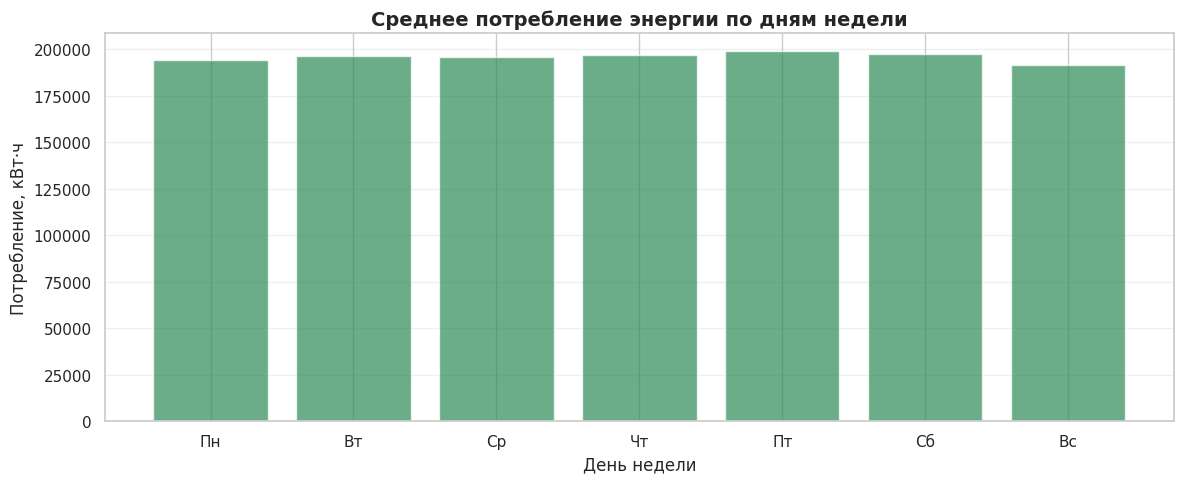

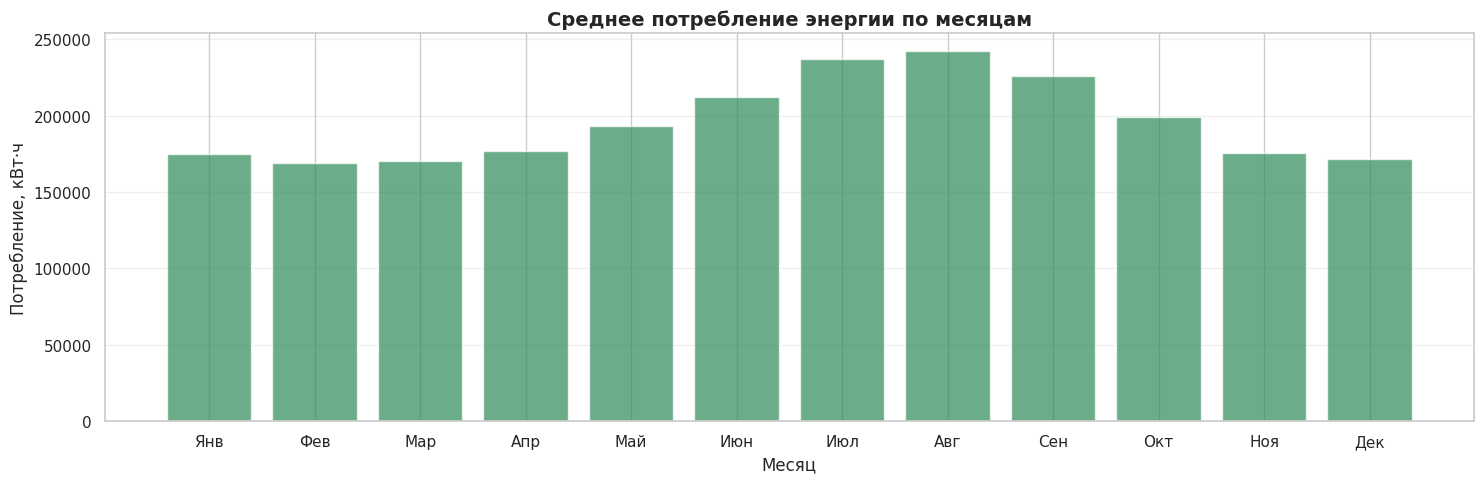

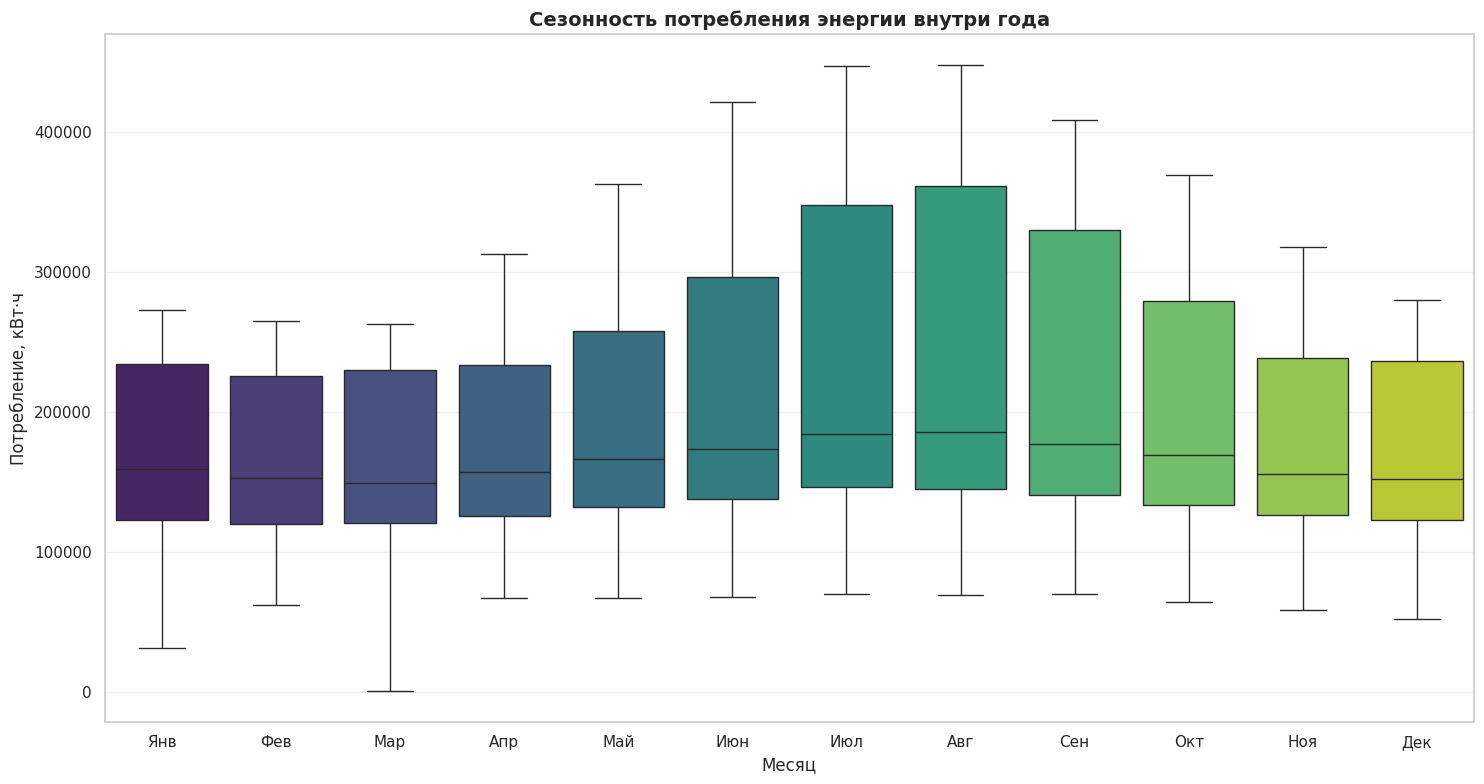

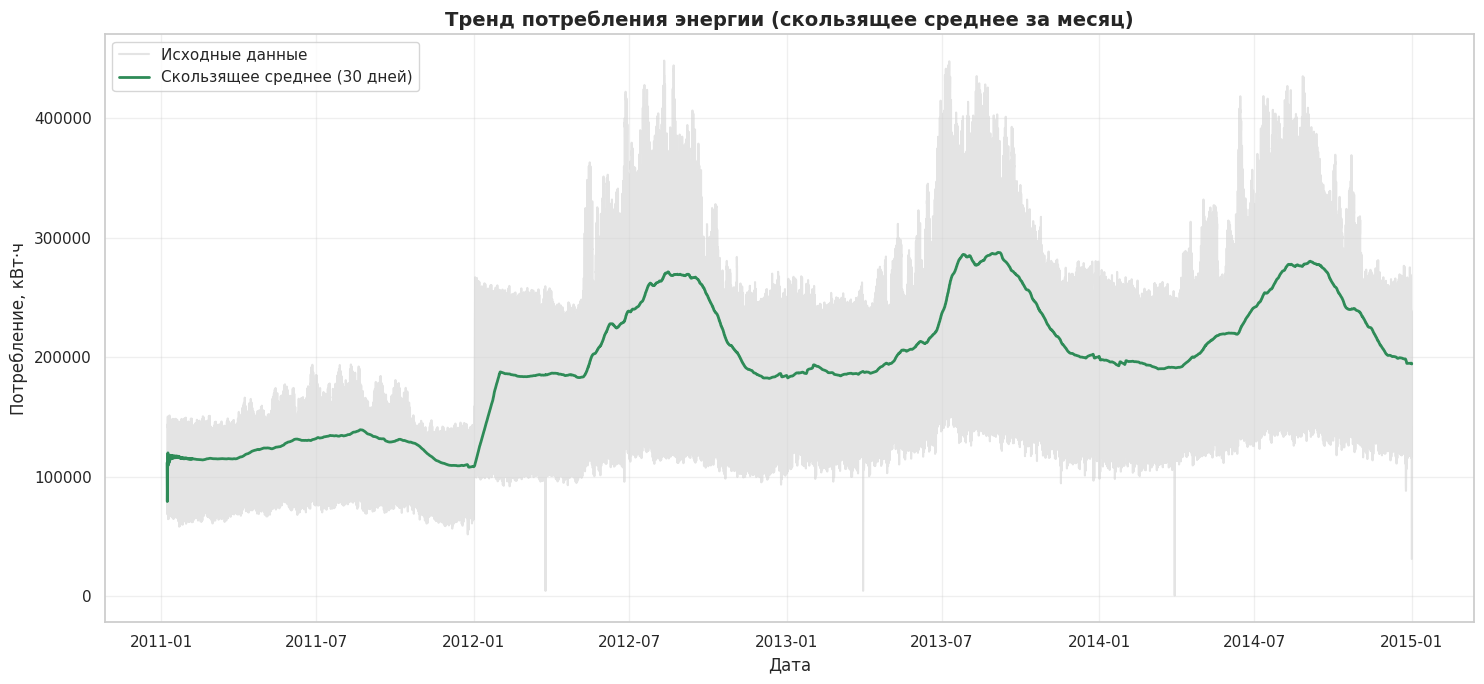

In [ ]:
sns.set_theme(style="whitegrid")

# График 1: Распределение количества заказов
plt.figure(figsize=(15, 5))
sns.histplot(df_sum['total_cons'], bins=50, kde=True, color='seagreen')
plt.title('Распределение потребления электроэнергии', fontsize=14, fontweight='bold')
plt.xlabel('Потребление')
plt.ylabel('Частота')
plt.show()

# график 2: Боксплот
plt.figure(figsize=(15, 5))
sns.boxplot(df_sum['total_cons'], orient='h', color='seagreen', boxprops={"alpha": 0.7})
plt.title('Выбросы', fontsize=14, fontweight='bold')
plt.show()

# График 3.1: Распределение потребления по часам
# Группируем по дням часам и считаем среднее потребление
hourly_avg = df_sum.groupby('hour')['total_cons'].mean()
plt.figure(figsize=(12, 5))
plt.bar(hourly_avg.index, hourly_avg.values, color='seagreen', alpha=0.7)
plt.title('Среднее потребление энергии по часам', fontsize=14, fontweight='bold')
plt.xlabel('Час', fontsize=12)
plt.ylabel('Потребление, кВт·ч', fontsize=12)
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# График 3.2: Распределение потребления по дням недели
# Группируем по дням недели и считаем среднее потребление
daily_avg = df_sum.groupby('day_of_week')['total_cons'].mean()
# Названия дней недели на русском
days_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
plt.figure(figsize=(12, 5))
plt.bar(daily_avg.index, daily_avg.values, color='seagreen', alpha=0.7)
plt.title('Среднее потребление энергии по дням недели', fontsize=14, fontweight='bold')
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Потребление, кВт·ч', fontsize=12)
plt.xticks(range(7), days_names)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# График 3.3: Распределение потребления по месяцам
# Группируем по месяцам и считаем среднее потребление
monthly_avg = df_sum.groupby('month')['total_cons'].mean()

plt.figure(figsize=(15, 5))
plt.bar(monthly_avg.index, monthly_avg.values, color='seagreen', alpha=0.7)
plt.title('Среднее потребление энергии по месяцам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Потребление, кВт·ч', fontsize=12)
plt.xticks(range(1, 13), ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                            'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# График 4: Сезонность потребления энергии внутри года
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_sum, x='month', y='total_cons', palette='viridis')
plt.title('Сезонность потребления энергии внутри года', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Потребление, кВт·ч', fontsize=12)
plt.xticks(range(0, 12), ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                         'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# График 5: Тренд (скользящее среднее за месяц) по годам
# Рассчитываем скользящее среднее за 30 дней (примерно месяц)
df_sum['rolling_avg'] = df_sum['total_cons'].rolling(window=720, min_periods=1).mean()  # 720 часов = 30 дней

plt.figure(figsize=(15, 7))
plt.plot(df_sum.index, df_sum['total_cons'], label='Исходные данные', alpha=0.6, color='lightgray')
plt.plot(df_sum.index, df_sum['rolling_avg'], label='Скользящее среднее (30 дней)', color='seagreen', linewidth=2)
plt.title('Тренд потребления энергии (скользящее среднее за месяц)', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Потребление, кВт·ч', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Разделение на признаки и таргет

In [ ]:
X = df_sum.drop('total_cons', axis=1)
y = df_sum['total_cons']

# Метрики оценки

In [ ]:
mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mape': mape_scorer
}

In [ ]:
print(f'Среднее потребление: {y.mean():.1f} кВт*ч')

Среднее потребление: 195950.6 кВт*ч


# Модели

## '1. Elastic Net

In [ ]:
eln_grid = {'model': Pipeline([
            ('scaler', RobustScaler()),
            ('regressor', ElasticNet(random_state=random_seed, max_iter=2000))
        ]),
        'params': {
            'regressor__alpha': [0.1, 1.0, 5.0, 10.0],
            'regressor__l1_ratio': [0.1, 0.5, 0.7, 0.9]
        }
    }

In [ ]:
best_eln = train_model(X, y, eln_grid, test_size)

ElasticNet RMSE train/test: 4476.2 / 5078.6
ElasticNet MAPE train/test: 0.018% / 2.038%


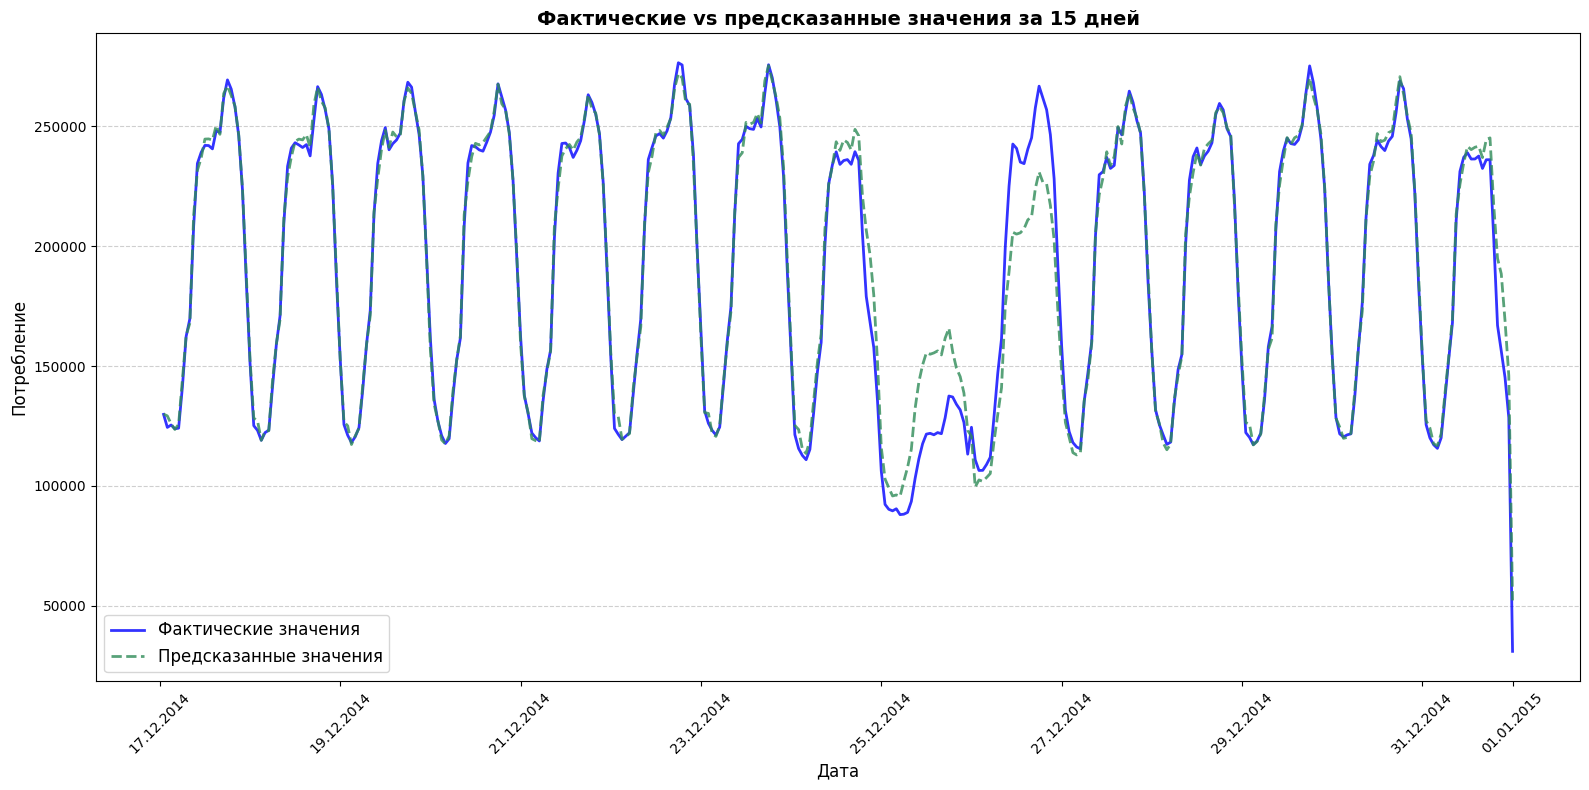

In [ ]:
comp_chart(y, best_eln['ElasticNet']['model'].predict(X), 15)

## '2. RandomForest

In [ ]:
rmf_grid = {'model': RandomForestRegressor(random_state=random_seed),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 15],
            'min_samples_split': [5, 10]
        }
    }

In [ ]:
best_rmf = train_model(X, y, rmf_grid, test_size)

RandomForestRegressor RMSE train/test: 15008.0 / 6142.2
RandomForestRegressor MAPE train/test: 0.046% / 2.718%


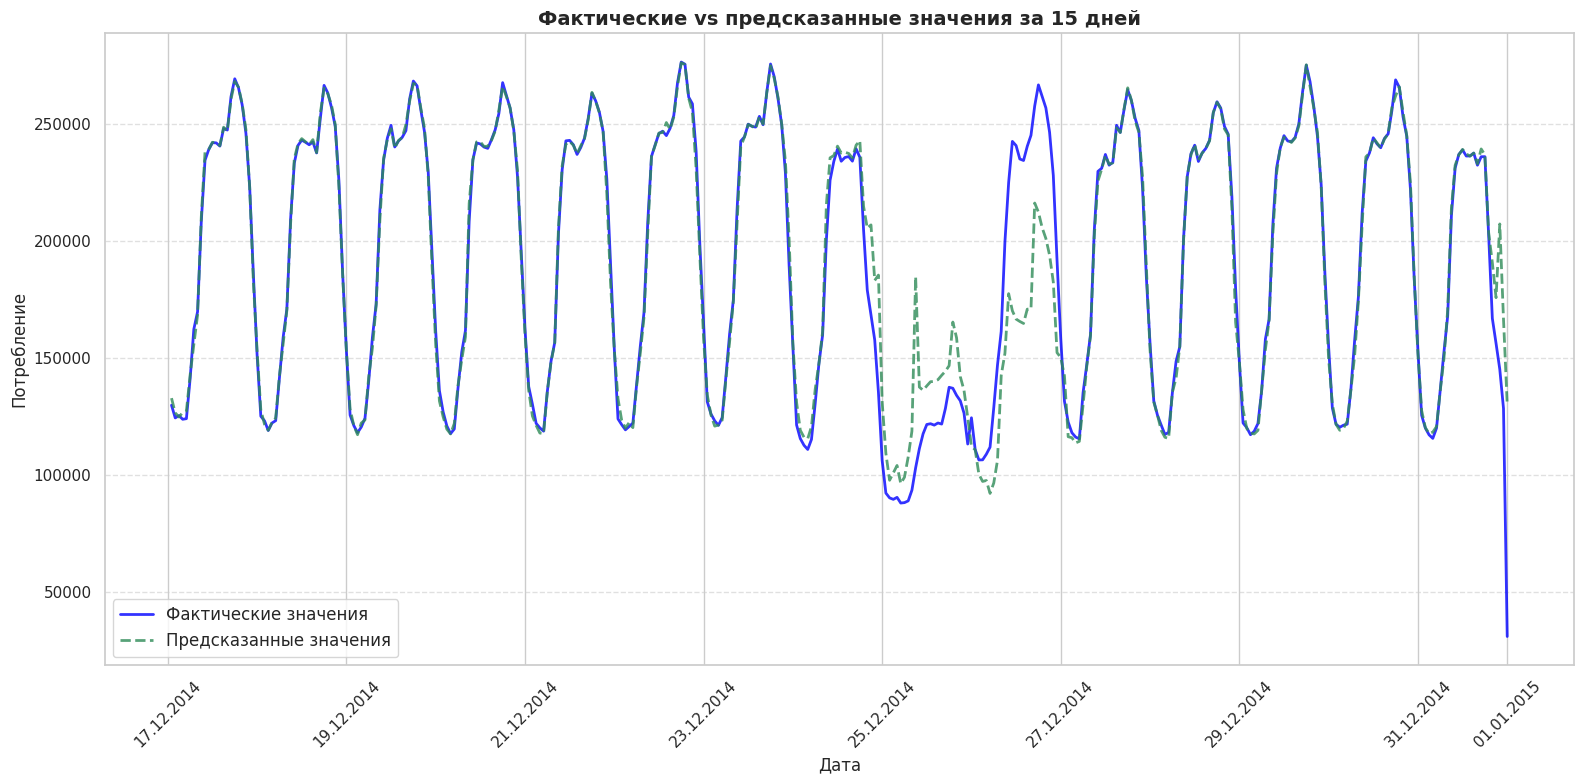

In [ ]:
comp_chart(y, best_rmf['RandomForestRegressor']['model'].predict(X), 15)

## '3. XGBoost

In [ ]:
xgb_grid = {'model': XGBRegressor(random_state=random_seed, objective='reg:squarederror'),
            'params': {
            'n_estimators': [100, 250],
            'learning_rate': [0.01, 0.1, 0.5],
            'max_depth': [4, 8]
        }
    }

In [ ]:
best_xgb = train_model(X, y, xgb_grid, test_size)

XGBRegressor RMSE train/test: 14901.1 / 3062.9
XGBRegressor MAPE train/test: 0.042% / 0.948%


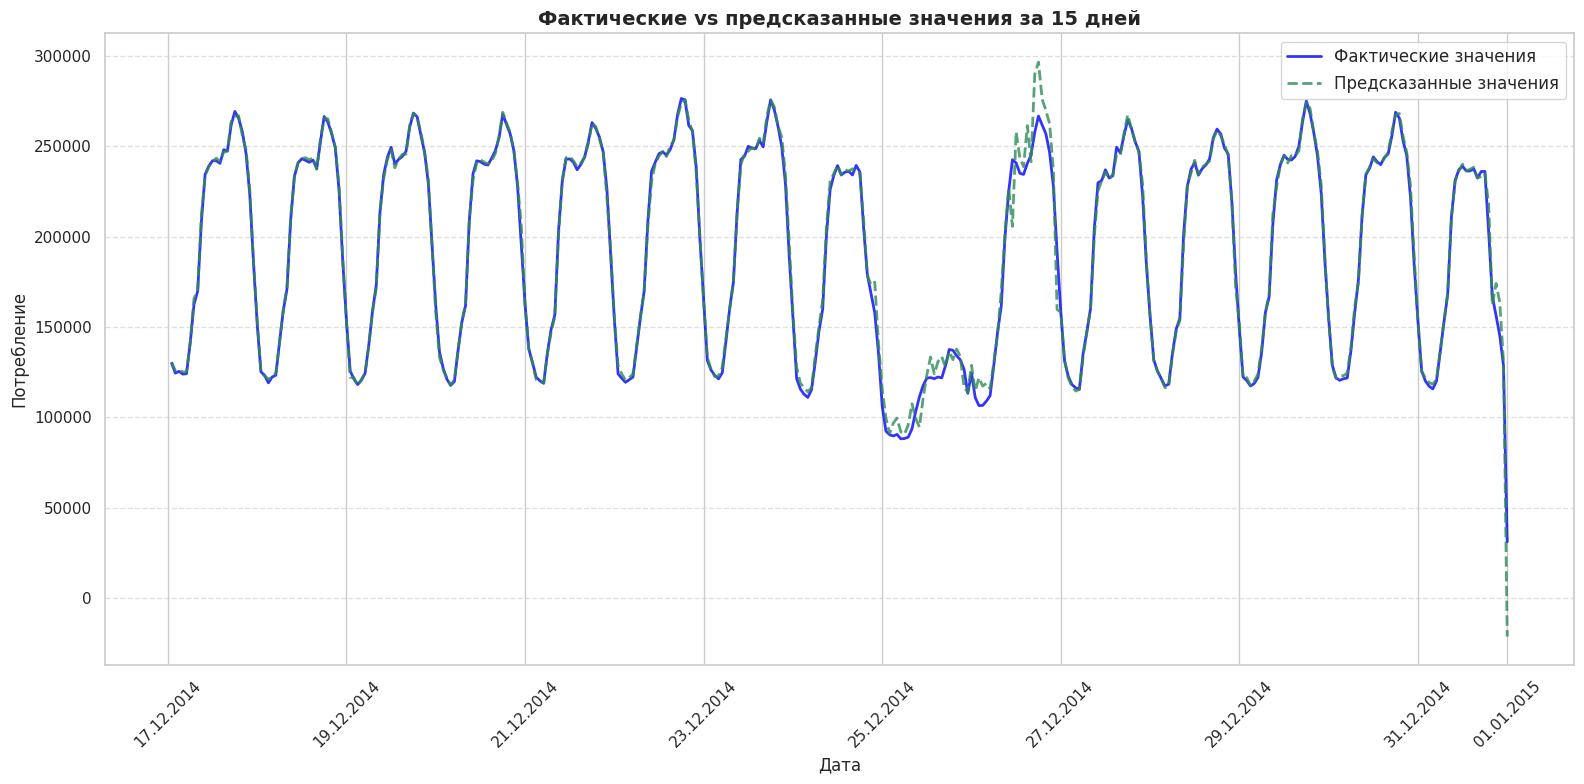

In [ ]:
comp_chart(y, best_xgb['XGBRegressor']['model'].predict(X), 15)

## '4. SARIMA

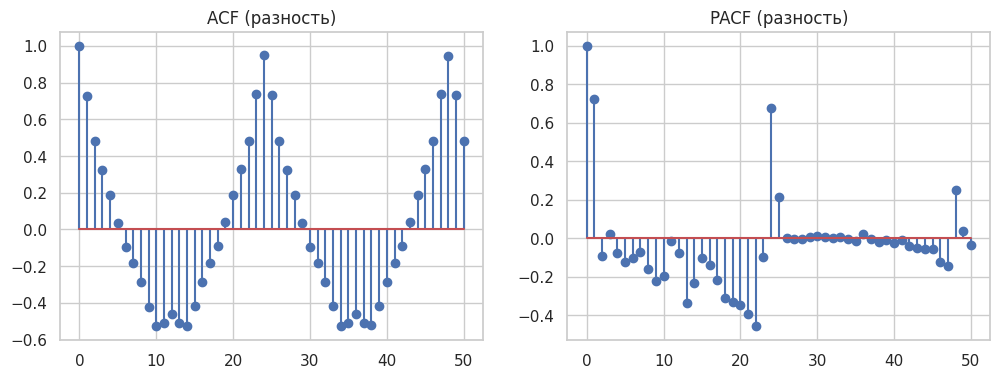

In [ ]:
# Разность для стационарности (d=1)
y_diff = y.diff().dropna()

# ACF и PACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.stem(acf(y_diff, nlags=50))
ax1.set_title('ACF (разность)')
ax2.stem(pacf(y_diff, nlags=50))
ax2.set_title('PACF (разность)')
plt.show()

Как читать графики:

- ACF: показывает корреляцию с лагами. Резкий спад после лага q подсказывает значение q.
- PACF: показывает прямую корреляцию. Резкий спад после лага p подсказывает значение p.
Сезонность: пики на 24, 168 (сутки/неделя) подскажут P и Q в сезонной части.

### Доработка
Для подбора параметров модели SARIMA по графикам ACF и PACF (построенным **по разности** ряда) нужно анализировать, где наблюдаются значимые пики (выходящие за красную линию доверительного интервала).

### 1. Определение несезонных параметров (p, q)

Эти параметры описывают краткосрочную зависимость (внутри суток/недели).

*   **Параметр `p` (AR-порядок, по PACF):**
    На графике **PACF** (справа) видно, что значимые пики (выше красной линии) затухают начиная с лага **1** и далее. Резкий спад начинается после первых 1–2 лагов.
    **Вывод:** `p = 1` (или максимум 2).

*   **Параметр `q` (MA-порядок, по ACF):**
    На графике **ACF** (слева) значимые пики также начинаются с лага **1** и быстро затухают.
    **Вывод:** `q = 1` (или максимум 2).

### 2. Определение сезонных параметров (P, Q)

Учитывая, что у вас данные почасовые и есть сезонность внутри года (рост с мая по октябрь), а также суточные колебания, нужно проверить сезонные лаги.

*   **Сезонный период `s`:**
    Поскольку у вас явная годовая сезонность, логично взять `s = 24 * 30 ~ 720` (часов в месяце) или `s = 24 * 365 = 8760` (часов в году). Однако для упрощения часто берут `s = 24` (суточный цикл) или `s = 168` (недельный цикл), если годовая сезонность выражена слабее.
    *   **Рекомендация:** начните с `s = 24` (суточный цикл), так как пики на ACF/PACF видны на малых лагах.

*   **Сезонный `P` (SAR, по PACF):**
    Посмотрите на график **PACF** — есть ли пики на кратных `s` лагах (например, 24, 48, 72...). На вашем графике видны «облака» значимых корреляций на лагах 20–30 и 40–50.
    **Вывод:** `P = 1` (учитываем один сезонный авторегрессионный член).

*   **Сезонный `Q` (SMA, по ACF):**
    На графике **ACF** также есть значимые пики на лагах 20–30 и 40–50.
    **Вывод:** `Q = 1`.

### 3. Параметры дифференцирования (d, D)

*   **`d` (обычная разность):** Поскольку вы уже построили графики по **разности** (как указано в заголовках), ряд уже стал стационарным. Значит, `d = 1`.
*   **`D` (сезонная разность):** Если при `d=1` остатки всё ещё имеют сезонный паттерн, попробуйте `D=1`. Если остатки выглядят как белый шум — оставьте `D=0`.

### Итоговый рекомендуемый набор параметров

Исходя из визуального анализа, стартовым вариантом модели будет:

```python
SARIMA(p=1, d=1, q=1, P=1, D=0, Q=1, s=24)
```

**Что это значит:**
- `p=1, q=1`: учитываем краткосрочную зависимость (1 час назад).
- `P=1, Q=1, s=24`: учитываем суточную сезонность (зависимость от значения 24 часа назад).
- `d=1`: ряд был продифференцирован один раз (вычли предыдущее значение).
- `D=0`: сезонная разность не применялась (можно попробовать `D=1`, если остатки будут «шумными»).


In [ ]:
# Параметры модели
p, d, q = 1, 1, 1
P, D, Q, s = 1, 0, 1, 24

srm_model = SARIMAX(
    y,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    initialization='approximate_diffuse'
)

srm_results = srm_model.fit()

In [ ]:
print(srm_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         total_cons   No. Observations:                34898
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 24)   Log Likelihood             -353809.833
Date:                            Wed, 17 Jun 2026   AIC                         707629.665
Time:                                    11:43:13   BIC                         707671.966
Sample:                                01-07-2011   HQIC                        707643.141
                                     - 01-01-2015                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9999      0.000  -2123.288      0.000      -1.001      -0.999
ma.L1          0.9999      0.000   

**Что получилось хорошо:**

- Модель корректно подобрала структуру (суточные циклы видны).
- Коэффициенты логичны с точки зрения временных рядов.

**Что требует доработки:**

- Распределение остатков далеко от нормального — нужно проверить наличие выбросов в данных.
- Автокорреляция в остатках (Ljung-Box) — попробуйте усложнить модель (добавить лаги).
- Численная сингулярность — самый опасный момент. Попробуйте:
применить логарифмическое преобразование данных (np.log(y)), чтобы уменьшить разброс значений;
проверить, нет ли в данных мультиколлинеарности (слишком похожих признаков);
уменьшить количество параметров модели, если это возможно.


In [ ]:
# Параметры модели
p, d, q = 1, 1, 1
P, D, Q, s = 1, 0, 1, 24

# Шаг 1. Логарифмирование данных (преобразование)
y_log = np.log(y)

# Шаг 2. Создание и обучение модели на логарифмированных данных
srm_model = SARIMAX(
    y_log,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    initialization='approximate_diffuse'
)

srm_results = srm_model.fit()

Прогноз в исходных единицах (кВт·ч):
2015-01-01 01:00:00     55991.406149
2015-01-01 02:00:00     58768.099308
2015-01-01 03:00:00     58064.375616
2015-01-01 04:00:00     57956.382106
2015-01-01 05:00:00     58768.934082
2015-01-01 06:00:00     66190.399058
2015-01-01 07:00:00     74002.561516
2015-01-01 08:00:00     79570.183640
2015-01-01 09:00:00     98570.639782
2015-01-01 10:00:00    110278.460429
2015-01-01 11:00:00    113833.232793
2015-01-01 12:00:00    115581.319176
2015-01-01 13:00:00    114238.246755
2015-01-01 14:00:00    114102.504778
2015-01-01 15:00:00    115911.349024
2015-01-01 16:00:00    116339.592473
2015-01-01 17:00:00    121245.089673
2015-01-01 18:00:00    125192.096179
2015-01-01 19:00:00    120862.852017
2015-01-01 20:00:00    114390.036269
2015-01-01 21:00:00    110201.843086
2015-01-01 22:00:00    100962.875837
2015-01-01 23:00:00     84924.951653
2015-01-02 00:00:00     62331.075168
Freq: h, Name: predicted_mean, dtype: float64


In [ ]:
print(srm_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         total_cons   No. Observations:                34898
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 24)   Log Likelihood               52075.430
Date:                            Wed, 17 Jun 2026   AIC                        -104140.861
Time:                                    11:52:29   BIC                        -104098.560
Sample:                                01-07-2011   HQIC                       -104127.385
                                     - 01-01-2015                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1153      0.001    151.125      0.000       0.114       0.117
ma.L1         -0.7130      0.001   

In [ ]:
# Box-Cox преобразование (возвращает преобразованный ряд и лямбда)
y_transformed, lambda_bc = boxcox(y)

print(f"Оптимальная лямбда Box-Cox: {lambda_bc}")

p, d, q = 1, 1, 2  # увеличили q с 1 до 2
P, D, Q, s = 1, 0, 1, 24

# Обучение модели на преобразованных данных
srm_model_v3 = SARIMAX(
    y_transformed,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    initialization='approximate_diffuse'
)
srm_v3_results = srm_model_v3.fit()

Оптимальная лямбда Box-Cox: 0.15510985488165707


In [ ]:
print(srm_v3_results.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                34898
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 24)   Log Likelihood               -4346.645
Date:                              Thu, 18 Jun 2026   AIC                           8705.290
Time:                                      11:24:59   BIC                           8756.051
Sample:                                           0   HQIC                          8721.461
                                            - 34898                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9101      0.002    563.436      0.000       0.907       0.913
ma.L1         -1.40

In [ ]:
# Шаг 1. Разделение данных (например, 80% на обучение, 20% на тест)
train_size = int(len(y) * (1 - test_size))
y_train = y[:train_size]
y_test = y[train_size:]

# Сохраняем индексы для визуализации (даты)
test_dates = y.index[train_size:]

# Шаг 2. Преобразование и обучение модели на обучающей выборке
y_train_transformed, lambda_bc = boxcox(y_train)  # Применяем Box-Cox к train

srm_model = SARIMAX(
    y_train_transformed,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    initialization='approximate_diffuse'
)
srm_results = srm_model.fit()

In [ ]:
print(srm_results.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                24428
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 24)   Log Likelihood               39186.658
Date:                              Thu, 18 Jun 2026   AIC                         -78361.316
Time:                                      11:26:04   BIC                         -78312.695
Sample:                                           0   HQIC                        -78345.561
                                            - 24428                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8473      0.002    433.185      0.000       0.843       0.851
ma.L1         -1.38

RMSE: 135879.18
MAPE: 47.47%


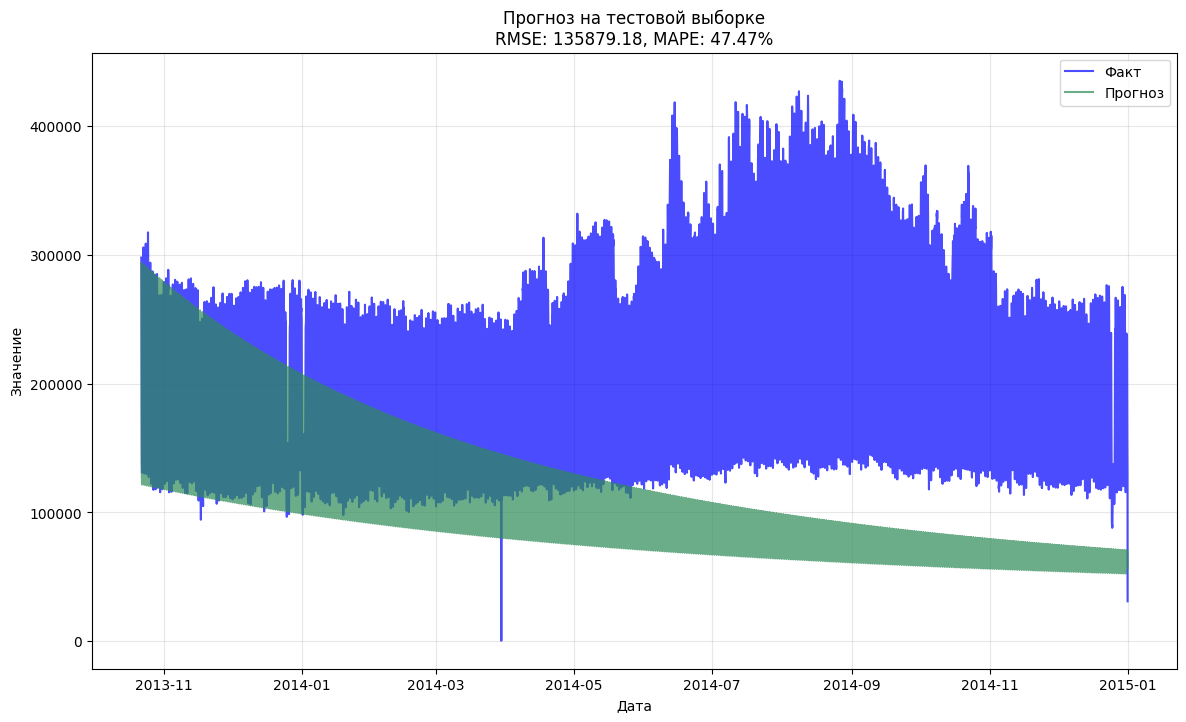

In [ ]:
# Шаг 3. Прогноз на тестовую выборку
forecast_steps = len(y_test)
forecast_transformed = srm_results.forecast(steps=forecast_steps)

# Шаг 4. Обратное преобразование прогноза (из Box-Cox в исходные единицы)
forecast_original = inv_boxcox(forecast_transformed, lambda_bc)

# Шаг 5. Расчёт метрик
rmse = np.sqrt(mean_squared_error(y_test, forecast_original))
mape = np.mean(np.abs((y_test - forecast_original) / y_test)) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Шаг 6. Визуализация
plt.figure(figsize=(14, 8))
plt.plot(test_dates, y_test, label='Факт', color='blue', alpha=0.7)
plt.plot(test_dates, forecast_original, label='Прогноз', color='seagreen', alpha=0.7)
plt.title(f'Прогноз на тестовой выборке\nRMSE: {rmse:.2f}, MAPE: {mape:.2f}%')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## '5. Экспоненциальное сглаживание

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
# Шаг 1. Разделение данных (например, 80% на обучение, 20% на тест)
train_size = int(len(y) * (1 - test_size))
y_train = y[:train_size]
y_test = y[train_size:]

# Создаем модель
model = ExponentialSmoothing(
    y_train,
    trend="additive",           # additive или multiplicative
    seasonal="additive",
    seasonal_periods=24
)

# Обучаем модель (находим оптимальные параметры сглаживания)
fitted_model = model.fit(optimized=True)

In [ ]:
# Делаем прогноз
forecast = fitted_model.forecast(steps=len(y_test))

In [ ]:
# Метрики
mse = mean_squared_error(y_test, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - forecast) / y_test)) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

RMSE: 39143.84
MAPE: 15.77%


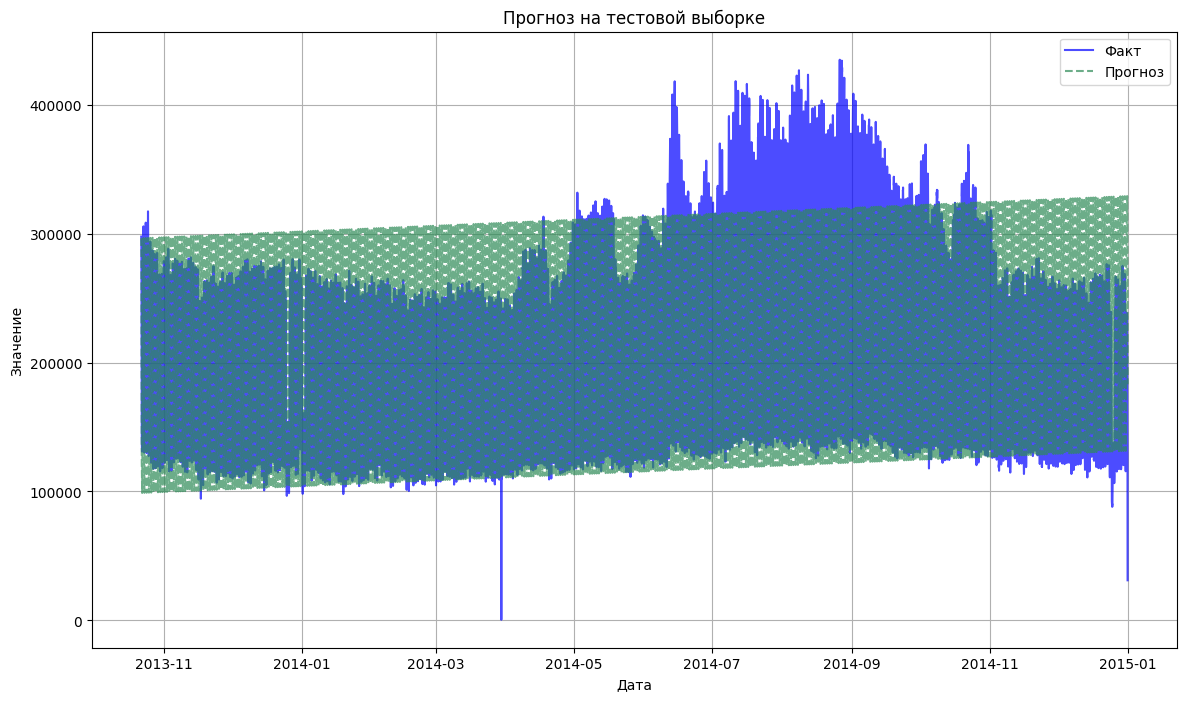

In [ ]:
plt.figure(figsize=(14, 8))
plt.plot(y_test.index, y_test.values, label='Факт', color='blue', alpha=0.7)
plt.plot(y_test.index, forecast.values, label='Прогноз', color='seagreen', linestyle='--', alpha=0.7)
plt.title('Прогноз на тестовой выборке')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True)
plt.show()

## '6. Prophet

In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

In [ ]:
# Создаём DataFrame с колонками ds (дата-время) и y (потребление)
df_prophet = pd.DataFrame({
    'ds': y.index,  # индекс с datetime становится колонкой ds
    'y': y.values   # значения потребления становятся колонкой y
})

# Сортируем по времени (на всякий случай)
df_prophet = df_prophet.sort_values('ds').reset_index(drop=True)

test_size = 0.3
train_size = int(len(df_prophet) * (1 - test_size))

# Разделяем DataFrame целиком
train_df = df_prophet[:train_size]
test_df = df_prophet[train_size:]

print(f"Тренировочные данные: {len(train_df)} записей, период: {train_df['ds'].min()} — {train_df['ds'].max()}")
print(f"Тестовые данные: {len(test_df)} записей, период: {test_df['ds'].min()} — {test_df['ds'].max()}")

Тренировочные данные: 24428 записей, период: 2011-01-07 23:00:00 — 2013-10-21 18:00:00
Тестовые данные: 10470 записей, период: 2013-10-21 19:00:00 — 2015-01-01 00:00:00


In [ ]:
# Создание и настройка модели
prh_model = Prophet(
    yearly_seasonality=True,      # годовая сезонность
    weekly_seasonality=False,     # недельная не нужна — учтём через daily
    daily_seasonality=True,       # суточная сезонность
    changepoint_prior_scale=0.05,  # гибкость тренда
    seasonality_prior_scale=10.0,  # сила сезонности
    holidays_prior_scale=5.0,    # влияние праздников
    interval_width=0.95         # ширина доверительного интервала
)

# Добавление дополнительных сезонностей
prh_model.add_seasonality(
    name='hourly',
    period=1/24,  # период в долях дня
    fourier_order=10
)
prh_model.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=5
)

# Обучение модели
prh_model.fit(train_df)

In [ ]:
# Создаём future только для периода теста
future_test = prh_model.make_future_dataframe(
    periods=len(test_df),
    freq='H'  # почасовые данные
)
# Прогнозируем только на тестовый период
forecast_test = prh_model.predict(future_test)
# Берём только прогнозы для тестового периода (последние N строк)
forecast_test = forecast_test[-len(test_df):]

In [ ]:
# RMSE
rmse = np.sqrt(mean_squared_error(test_df['y'], forecast_test['yhat']))

# MAPE (в процентах)
mape = mean_absolute_percentage_error(test_df['y'], forecast_test['yhat']) * 100

print(f"RMSE на тестовых данных: {rmse:.2f}")
print(f"MAPE на тестовых данных: {mape:.2f}%")

RMSE на тестовых данных: 51648.21
MAPE на тестовых данных: 27.16%


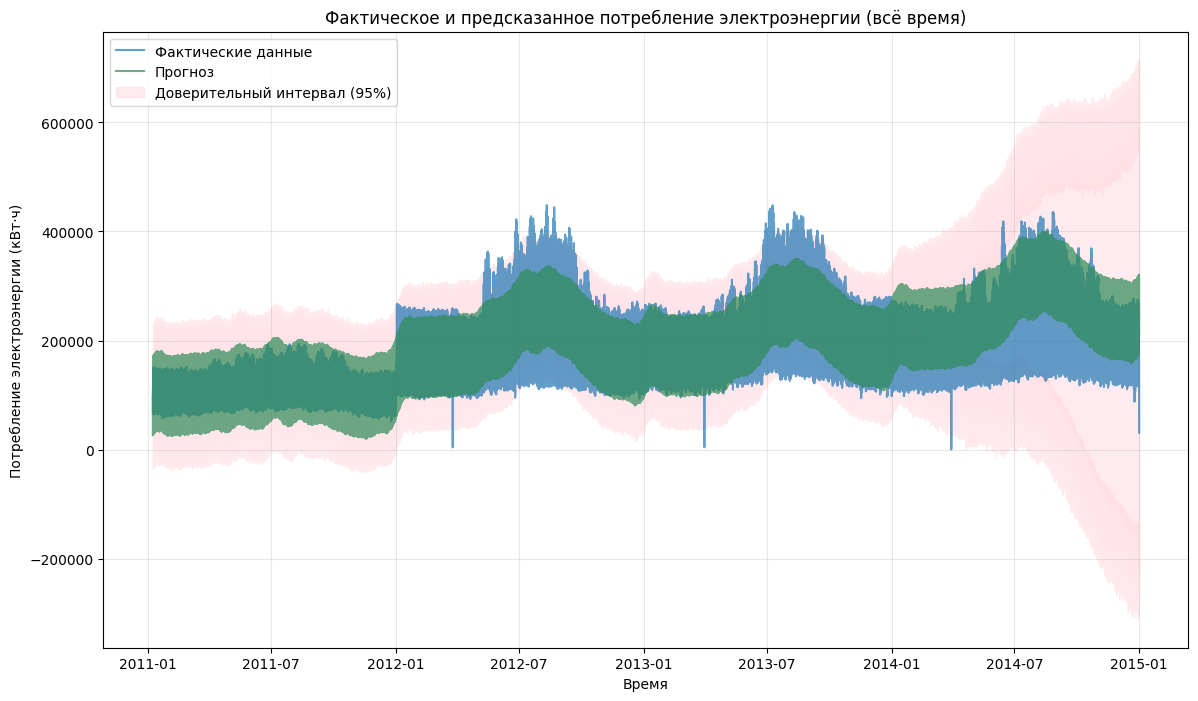

In [ ]:
# Получаем прогнозы для тренировочного периода
future_train = prh_model.make_future_dataframe(
    periods=len(train_df),
    freq='H'
)
forecast_train = prh_model.predict(future_train)
forecast_train = forecast_train[:len(train_df)]  # берём только исторические прогнозы

# Объединяем прогнозы
full_forecast = pd.concat([forecast_train, forecast_test], ignore_index=True)

plt.figure(figsize=(14, 8))
plt.plot(df_prophet['ds'], df_prophet['y'], label='Фактические данные', alpha=0.7)
plt.plot(full_forecast['ds'], full_forecast['yhat'], label='Прогноз', color='seagreen', alpha=0.7)
plt.fill_between(
    full_forecast['ds'],
    full_forecast['yhat_lower'],
    full_forecast['yhat_upper'],
    color='pink',
    alpha=0.3,
    label='Доверительный интервал (95%)'
)
plt.title('Фактическое и предсказанное потребление электроэнергии (всё время)')
plt.xlabel('Время')
plt.ylabel('Потребление электроэнергии (кВт·ч)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

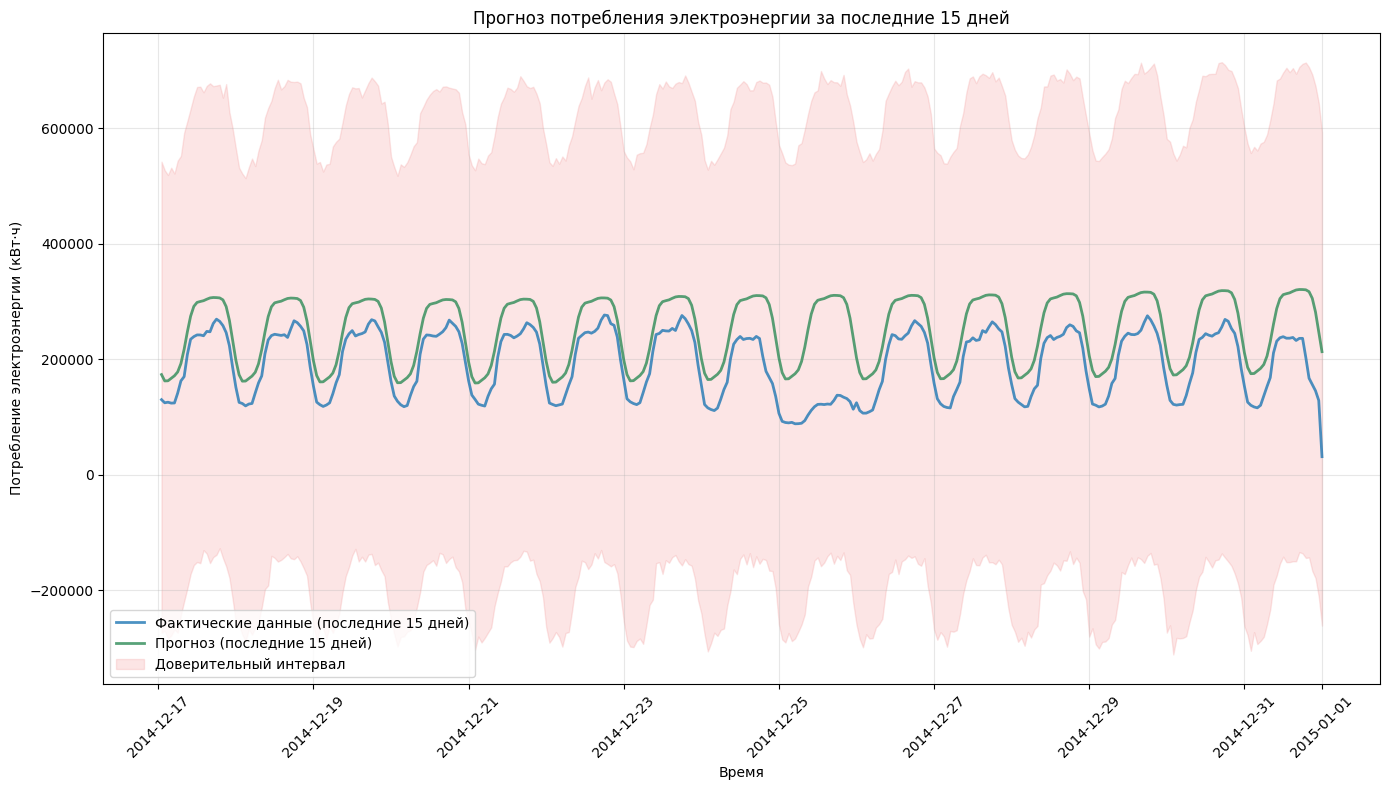

In [ ]:
# Последние 15 дней тестовых данных
last_15_days = test_df[-360:]  # 15 дней × 24 часа = 360 точек
last_15_forecast = forecast_test[-360:]

plt.figure(figsize=(14, 8))
plt.plot(last_15_days['ds'], last_15_days['y'],
         label='Фактические данные (последние 15 дней)', alpha=0.8, linewidth=2)
plt.plot(last_15_forecast['ds'], last_15_forecast['yhat'],
         label='Прогноз (последние 15 дней)', color='seagreen', linewidth=2, alpha=0.8)
plt.fill_between(
    last_15_forecast['ds'],
    last_15_forecast['yhat_lower'],
    last_15_forecast['yhat_upper'],
    color='lightcoral',
    alpha=0.2,
    label='Доверительный интервал'
)
plt.title('Прогноз потребления электроэнергии за последние 15 дней')
plt.xlabel('Время')
plt.ylabel('Потребление электроэнергии (кВт·ч)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

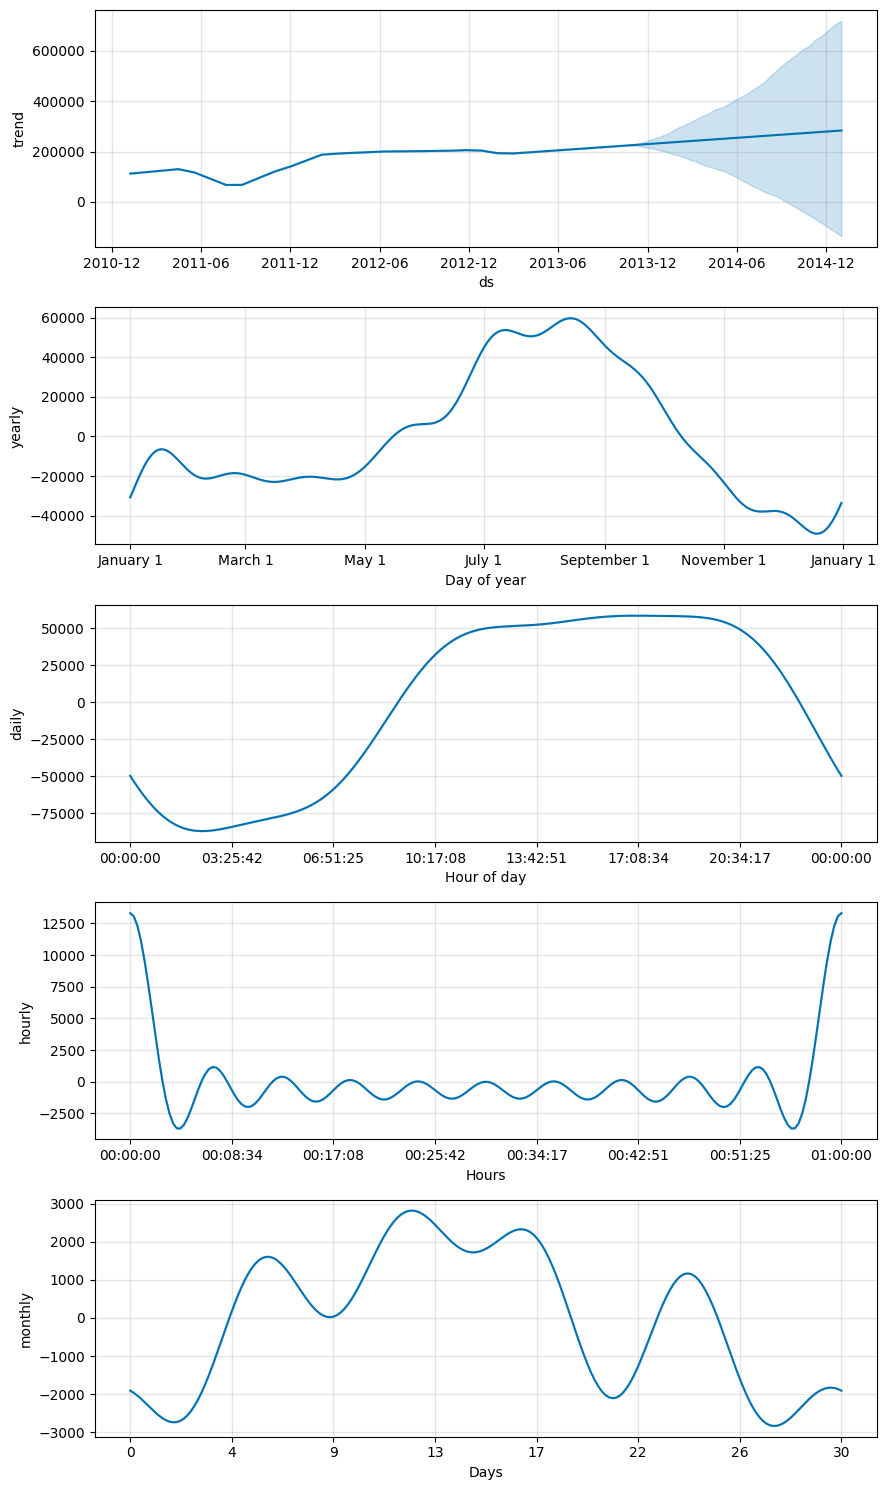

In [ ]:
# Визуализация компонент модели
fig_components = model.plot_components(forecast)
plt.show()

# Вывод

- Обычные модели (линейная, RF, XGB) показали существенно лучшие результаты. Специализированные под временные ряды, нужно настраивать.
- Лидер XGB.

# Разобрать код!

In [ ]:
#  Тройное экспоненциальное сглаживание (метод Хольт - Винтерса) (TEMA)
def triple_exponential_smoothing(series, slen, alpha, beta, gamma, n_preds):
    result = []
    seasonals = initial_seasonal_components(series, slen)
    for i in range(len(series)+n_preds):
        if i == 0: # initial values
            smooth = series[0]
            trend = sum([float(series[i + slen] - series[i]) / slen]) / slen
            result.append(series[0])
            continue
        if i >= len(series): # we are forecasting
            m = i - len(series) + 1
            result.append((smooth + m*trend) + seasonals[i%slen])
        else:
            val = series[i]
            last_smooth, smooth = smooth, alpha*(val-seasonals[i%slen]) + (1-alpha)*(smooth+trend)
            trend = beta * (smooth-last_smooth) + (1-beta)*trend
            seasonals[i%slen] = gamma*(val-smooth) + (1-gamma)*seasonals[i%slen]
            result.append(smooth+trend+seasonals[i%slen])
    return result

#